# MoveOD Figures 1–2 (Repeatability)

This notebook generates Figure 1 (OD map) and Figure 2 (departure-time distribution) from a completed MoveOD run.

**Default scenario**: Tennessee / Hamilton.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
STATE = "Tennessee"
COUNTY = "Hamilton"
RUN_ID = None  # e.g., "2025-03-10_2025-03-10" or leave None for latest
OUTPUT_ROOT = Path("..") / "move_OD"
OUT_DIR = Path("..") / "plots" / "figures"
OUT_DIR.mkdir(parents=True, exist_ok=True)

def find_run_dir():
    base = OUTPUT_ROOT / STATE / COUNTY
    if RUN_ID:
        return base / RUN_ID
    runs = sorted([p for p in base.iterdir() if p.is_dir()])
    if not runs:
        raise FileNotFoundError(f"No runs found under {base}")
    return runs[-1]

def pick_first_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    lower_map = {c.lower(): c for c in df.columns}
    for c in candidates:
        if c.lower() in lower_map:
            return lower_map[c.lower()]
    return None

run_dir = find_run_dir()
calib_dir = run_dir / "calibrated_move_od"
calib_files = sorted(calib_dir.glob("*.csv"))
if not calib_files:
    raise FileNotFoundError(f"No calibrated CSVs found in {calib_dir}")
calib_csv = calib_files[-1]
print(f"Using calibrated file: {calib_csv}")

df = pd.read_csv(calib_csv)

# Optional: initial (pre-calibration) outputs
lodes_dir = run_dir / "lodes_combs"
lodes_files = sorted(lodes_dir.glob("lodes_*.csv"))
df_initial = pd.read_csv(lodes_files[-1]) if lodes_files else None
if lodes_files:
    print(f"Using initial file: {lodes_files[-1]}")

# Optional: census distributions
census_dir = run_dir / "census_data"
dept_path = census_dir / "census_depart_times.csv"
tt_path = census_dir / "travel_time_to_work.csv"
dept_df = pd.read_csv(dept_path) if dept_path.exists() else None
tt_df = pd.read_csv(tt_path) if tt_path.exists() else None
if dept_df is None:
    print("No census_depart_times.csv found; Figure 1 will show generated only.")
if tt_df is None:
    print("No travel_time_to_work.csv found; Figure 2 will show generated only.")

Using calibrated file: ../move_OD/Tennessee/Hamilton/2025-03-10_2025-03-10/calibrated_move_od/2025-03-10.csv
Using initial file: ../move_OD/Tennessee/Hamilton/2025-03-10_2025-03-10/lodes_combs/lodes_2025-03-10.csv


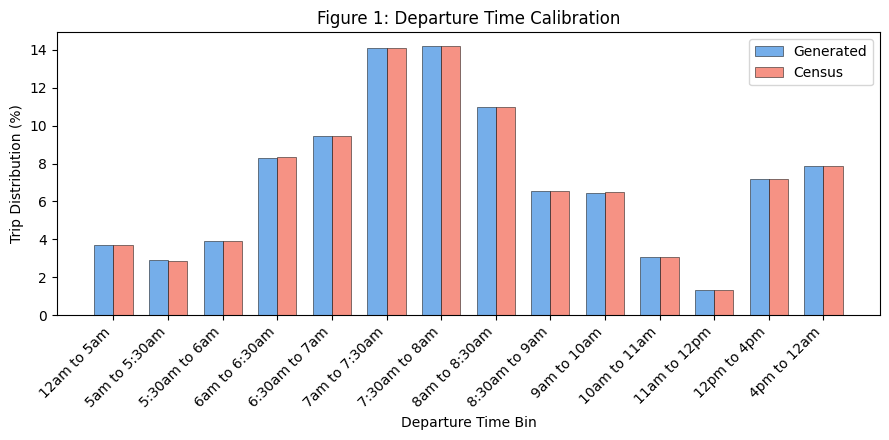

Saved Figure 1 to: ../plots/figures/fig1_departure_time_calibration.png


In [ ]:
# Figure 1: Departure time distribution (Generated vs Census)
import numpy as np

# ACS-style departure time bins
dep_bins = [0, 5*3600, int(5.5*3600), 6*3600, int(6.5*3600), 7*3600, int(7.5*3600),
            8*3600, int(8.5*3600), 9*3600, 10*3600, 11*3600, 12*3600, 16*3600, 24*3600]
dep_labels = ["12am to 5am", "5am to 5:30am", "5:30am to 6am", "6am to 6:30am", "6:30am to 7am",
              "7am to 7:30am", "7:30am to 8am", "8am to 8:30am", "8:30am to 9am", "9am to 10am",
              "10am to 11am", "11am to 12pm", "12pm to 4pm", "4pm to 12am"]

def get_departure_seconds(frame):
    sec_col = "departure_time"
    return pd.to_numeric(frame[sec_col], errors="coerce").dropna()
    
def census_departure_pct_from_wide(frame):
    wide_map = {
        "12am_to_4:59am_estimate": "12am to 5am",
        "5am_to_5:29am_estimate": "5am to 5:30am",
        "5:30am_to_5:59am_estimate": "5:30am to 6am",
        "6am_to_6:29am_estimate": "6am to 6:30am",
        "6:30am_to_6:59am_estimate": "6:30am to 7am",
        "7am_to_7:29am_estimate": "7am to 7:30am",
        "7:30am_to_7:59am_estimate": "7:30am to 8am",
        "8am_to_8:29am_estimate": "8am to 8:30am",
        "8:30am_to_8:59am_estimate": "8:30am to 9am",
        "9am_to_9:59am_estimate": "9am to 10am",
        "10am_to_10:59am_estimate": "10am to 11am",
        "11am_to_11:59am_estimate": "11am to 12pm",
        "12pm_to_3:59pm_estimate": "12pm to 4pm",
        "4pm_to_11:59pm_estimate": "4pm to 12am",
    }
    cols = [c for c in wide_map if c in frame.columns]
    if not cols:
        return None
    totals = frame[cols].apply(pd.to_numeric, errors="coerce").sum()
    total = totals.sum()
    if total == 0:
        return None
    pct = (totals / total * 100).rename(index=wide_map)
    return pct.reindex(dep_labels).fillna(0)

gen_seconds = get_departure_seconds(df)
gen_bins = pd.cut(gen_seconds, bins=dep_bins, labels=dep_labels, right=False, include_lowest=True)
gen_pct = (gen_bins.value_counts(normalize=True).reindex(dep_labels).fillna(0) * 100)

census_pct = None
if dept_df is not None:
    census_pct = census_departure_pct_from_wide(dept_df)
    if census_pct is None:
        label_col = pick_first_col(dept_df, ["time_bin", "time", "bin", "label", "departure_time_bin"])
        value_col = pick_first_col(dept_df, ["percent", "share", "pct", "percentage", "value"])
        if label_col is None or value_col is None:
            if dept_df.shape[1] >= 2:
                label_col, value_col = dept_df.columns[:2]
        if label_col and value_col:
            tmp = dept_df[[label_col, value_col]].copy()
            tmp[label_col] = tmp[label_col].astype(str).str.lower().str.replace(" ", "", regex=False)
            label_map = {
                "12amto5am": "12am to 5am",
                "5amto5:30am": "5am to 5:30am",
                "5:30amto6am": "5:30am to 6am",
                "6amto6:30am": "6am to 6:30am",
                "6:30amto7am": "6:30am to 7am",
                "7amto7:30am": "7am to 7:30am",
                "7:30amto8am": "7:30am to 8am",
                "8amto8:30am": "8am to 8:30am",
                "8:30amto9am": "8:30am to 9am",
                "9amto10am": "9am to 10am",
                "10amto11am": "10am to 11am",
                "11amto12pm": "11am to 12pm",
                "12pmto4pm": "12pm to 4pm",
                "4pmto12am": "4pm to 12am",
            }
            tmp["label"] = tmp[label_col].map(label_map)
            tmp = tmp.dropna(subset=["label"])
            census_pct = (
                tmp.groupby("label")[value_col].mean().reindex(dep_labels).fillna(0).astype(float)
            )

x = np.arange(len(dep_labels))
width = 0.35
plt.figure(figsize=(9, 4.5))
plt.bar(x - width/2, gen_pct.values, width, label="Generated", color="#5DA0E7", alpha=0.85, edgecolor="black", linewidth=0.4)
if census_pct is not None:
    plt.bar(x + width/2, census_pct.values, width, label="Census", color="#F57F6F", alpha=0.85, edgecolor="black", linewidth=0.4)
plt.xticks(x, dep_labels, rotation=45, ha="right")
plt.ylabel("Trip Distribution (%)")
plt.xlabel("Departure Time Bin")
plt.title("Figure 1: Departure Time Calibration")
plt.legend(loc="upper right")
plt.tight_layout()
fig1_path = OUT_DIR / "fig1_departure_time_calibration.png"
plt.savefig(fig1_path, dpi=200)
plt.show()
print(f"Saved Figure 1 to: {fig1_path}")

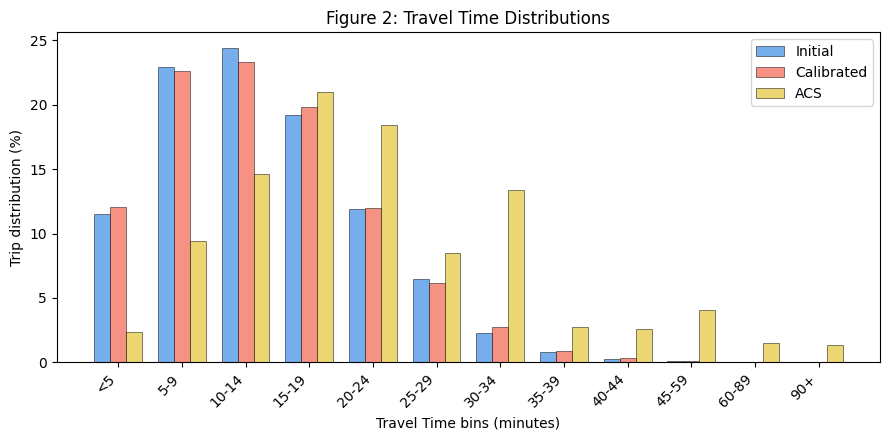

Saved Figure 2 to: ../plots/figures/fig2_travel_time_distribution.png


In [4]:
# Figure 2: Travel time distributions (Initial vs Calibrated vs ACS)
import numpy as np

tt_bins = [-1, 5, 10, 15, 20, 25, 30, 35, 40, 45, 60, 90, 10**9]
tt_labels = ["<5", "5-9", "10-14", "15-19", "20-24", "25-29", "30-34", "35-39", "40-44", "45-59", "60-89", "90+"]

def get_travel_time_minutes(frame):
    if frame is None:
        return None
    col = pick_first_col(frame, ["travel_time_min", "travel_time_minutes", "travel_time", "travel_time_to_work", "time_to_work"])
    if col is None:
        return None
    return pd.to_numeric(frame[col], errors="coerce").dropna()

def census_travel_pct_from_wide(frame):
    wide_map = {
        "under_5_minutes_estimate": "<5",
        "5_to_9_minutes_estimate": "5-9",
        "10_to_14_minutes_estimate": "10-14",
        "15_to_19_minutes_estimate": "15-19",
        "20_to_24_minutes_estimate": "20-24",
        "25_to_29_minutes_estimate": "25-29",
        "30_to_34_minutes_estimate": "30-34",
        "35_to_39_minutes_estimate": "35-39",
        "40_to_44_minutes_estimate": "40-44",
        "45_to_59_minutes_estimate": "45-59",
        "60_to_89_minutes_estimate": "60-89",
        "90_minutes_and_over_estimate": "90+",
    }
    cols = [c for c in wide_map if c in frame.columns]
    if not cols:
        return None
    totals = frame[cols].apply(pd.to_numeric, errors="coerce").sum()
    total = totals.sum()
    if total == 0:
        return None
    pct = (totals / total * 100).rename(index=wide_map)
    return pct.reindex(tt_labels).fillna(0)

calib_tt = get_travel_time_minutes(df)
init_tt = get_travel_time_minutes(df_initial)

def to_pct(series):
    if series is None or series.empty:
        return None
    bins = pd.cut(series, bins=tt_bins, labels=tt_labels, right=False, include_lowest=True)
    return (bins.value_counts(normalize=True).reindex(tt_labels).fillna(0) * 100)

calib_pct = to_pct(calib_tt)
init_pct = to_pct(init_tt)

acs_pct = None
if tt_df is not None:
    acs_pct = census_travel_pct_from_wide(tt_df)
    if acs_pct is None:
        label_col = pick_first_col(tt_df, ["time_bin", "bin", "label", "travel_time_bin"])
        value_col = pick_first_col(tt_df, ["percent", "share", "pct", "percentage", "value"])
        if label_col is None or value_col is None:
            if tt_df.shape[1] >= 2:
                label_col, value_col = tt_df.columns[:2]
        if label_col and value_col:
            tmp = tt_df[[label_col, value_col]].copy()
            tmp[label_col] = tmp[label_col].astype(str).str.replace(" ", "", regex=False).str.lower()
            label_map = {
                "<5": "<5",
                "5-9": "5-9",
                "10-14": "10-14",
                "15-19": "15-19",
                "20-24": "20-24",
                "25-29": "25-29",
                "30-34": "30-34",
                "35-39": "35-39",
                "40-44": "40-44",
                "45-59": "45-59",
                "60-89": "60-89",
                "90+": "90+",
                "90ormore": "90+",
                "60to89": "60-89",
                "45to59": "45-59",
                "40to44": "40-44",
                "35to39": "35-39",
                "30to34": "30-34",
                "25to29": "25-29",
                "20to24": "20-24",
                "15to19": "15-19",
                "10to14": "10-14",
                "5to9": "5-9",
            }
            tmp["label"] = tmp[label_col].map(label_map)
            tmp = tmp.dropna(subset=["label"])
            acs_pct = (
                tmp.groupby("label")[value_col].mean().reindex(tt_labels).fillna(0).astype(float)
            )

x = np.arange(len(tt_labels))
width = 0.25
plt.figure(figsize=(9, 4.5))
if init_pct is not None:
    plt.bar(x - width, init_pct.values, width, label="Initial", color="#5DA0E7", alpha=0.85, edgecolor="black", linewidth=0.4)
if calib_pct is not None:
    plt.bar(x, calib_pct.values, width, label="Calibrated", color="#F57F6F", alpha=0.85, edgecolor="black", linewidth=0.4)
if acs_pct is not None:
    plt.bar(x + width, acs_pct.values, width, label="ACS", color="#E9CF5A", alpha=0.85, edgecolor="black", linewidth=0.4)
plt.xticks(x, tt_labels, rotation=45, ha="right")
plt.ylabel("Trip distribution (%)")
plt.xlabel("Travel Time bins (minutes)")
plt.title("Figure 2: Travel Time Distributions")
plt.legend(loc="upper right")
plt.tight_layout()
fig2_path = OUT_DIR / "fig2_travel_time_distribution.png"
plt.savefig(fig2_path, dpi=200)
plt.show()
print(f"Saved Figure 2 to: {fig2_path}")